In [1]:
##Import relevant libraries

import pandas as pd
import numpy as np

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

from xgboost import XGBClassifier
import joblib

In [2]:
##Load dataset

df = pd.read_csv("C:/Users/Administrator/Downloads/fulfillment_data.csv")

df["date"] = pd.to_datetime(df["date"])

In [3]:
df.head()

,date,customer_code,region,product,orders_created,orders_dispatched,backlog_qty,available_funds,daily_target,depot_status,plant_status,truck_availability_index,dispatch_delay_days
0,2023-09-01,CUST_0001,Lagos,PMS,6,16,39,393944,10,Available,Running,0.34,1
1,2023-09-02,CUST_0001,Lagos,DPK,7,7,39,5486,9,Available,Running,0.69,2
2,2023-09-03,CUST_0001,Lagos,PMS,11,9,41,289336,11,Available,Running,0.34,0
3,2023-09-04,CUST_0001,Lagos,DPK,15,12,44,103150,16,Available,Maintenance,0.91,1
4,2023-09-05,CUST_0001,Lagos,AGO,8,5,47,39081,13,Low Stock,Running,0.36,0


In [4]:
##Sort by date

df = df.sort_values(["date", "customer_code"]).reset_index(drop=True)

In [5]:
df.head()

,date,customer_code,region,product,orders_created,orders_dispatched,backlog_qty,available_funds,daily_target,depot_status,plant_status,truck_availability_index,dispatch_delay_days
0,2023-09-01,CUST_0001,Lagos,PMS,6,16,39,393944,10,Available,Running,0.34,1
1,2023-09-01,CUST_0002,North,DPK,0,3,36,35903,14,Out of Stock,Running,0.57,1
2,2023-09-01,CUST_0003,East,AGO,13,4,50,94937,17,Low Stock,Running,0.51,2
3,2023-09-01,CUST_0004,Lagos,AGO,5,8,63,379570,12,Available,Running,0.58,0
4,2023-09-01,CUST_0005,Lagos,PMS,9,0,109,444639,11,Available,Running,0.90,1


In [6]:
##Creating targets

df["future_backlog_qty"] = (
    df.groupby("customer_code")["backlog_qty"]
    .shift(-7)
)


In [7]:
##Create Lag and Rolling features

df["backlog_lag_1"] = df.groupby("customer_code")["backlog_qty"].shift(1)
df["backlog_lag_7"] = df.groupby("customer_code")["backlog_qty"].shift(7)

df["dispatch_lag_1"] = df.groupby("customer_code")["orders_dispatched"].shift(1)
df["dispatch_lag_7"] = df.groupby("customer_code")["orders_dispatched"].shift(7)

df["backlog_roll_mean_7"] = (
    df.groupby("customer_code")["backlog_qty"]
    .transform(lambda x: x.shift(1).rolling(7).mean())
)

df["dispatch_roll_mean_7"] = (
    df.groupby("customer_code")["orders_dispatched"]
    .transform(lambda x: x.shift(1).rolling(7).mean())
)


In [8]:
##Create more ML features to improve model's performance

df["backlog_cover_days"] = df["backlog_qty"] / (df["daily_target"] + 1)

df["dispatch_rate"] = df["orders_dispatched"] / (df["backlog_qty"] + 1)

df["backlog_change"] = (
    df.groupby(["customer_code","product"])["backlog_qty"]
    .diff()
)

df["order_gap"] = df["orders_created"] - df["orders_dispatched"]

df["backlog_change"] = df["backlog_change"].fillna(0)


In [9]:
df = df.dropna().reset_index(drop=True)


In [10]:
df.head()

,date,customer_code,region,product,orders_created,orders_dispatched,backlog_qty,available_funds,daily_target,depot_status,...,backlog_lag_1,backlog_lag_7,dispatch_lag_1,dispatch_lag_7,backlog_roll_mean_7,dispatch_roll_mean_7,backlog_cover_days,dispatch_rate,backlog_change,order_gap
0,2023-09-08,CUST_0001,Lagos,DPK,10,8,50,61629,13,Available,...,48.0,39.0,1.0,16.0,43.142857,7.857143,3.571429,0.156863,6.0,2
1,2023-09-08,CUST_0002,North,AGO,15,5,24,229602,6,Available,...,14.0,36.0,6.0,3.0,19.142857,8.571429,3.428571,0.200000,-3.0,10
2,2023-09-08,CUST_0003,East,DPK,11,1,72,90715,14,Available,...,62.0,50.0,4.0,4.0,48.142857,6.714286,4.800000,0.013699,23.0,10
3,2023-09-08,CUST_0004,Lagos,AGO,11,11,69,385219,10,Available,...,69.0,63.0,9.0,8.0,66.714286,6.857143,6.272727,0.157143,0.0,0
4,2023-09-08,CUST_0005,Lagos,PMS,13,3,123,185431,18,Low Stock,...,113.0,109.0,3.0,0.0,109.000000,5.142857,6.473684,0.024194,22.0,10


In [11]:
##Choose features and target

drop_cols = [
    "date",
    "customer_code",
    "future_backlog_qty"
]

feature_cols = [c for c in df.columns if c not in drop_cols]

X = df[feature_cols]
y = df["future_backlog_qty"]

print(feature_cols)

['region', 'product', 'orders_created', 'orders_dispatched', 'backlog_qty', 'available_funds', 'daily_target', 'depot_status', 'plant_status', 'truck_availability_index', 'dispatch_delay_days', 'backlog_lag_1', 'backlog_lag_7', 'dispatch_lag_1', 'dispatch_lag_7', 'backlog_roll_mean_7', 'dispatch_roll_mean_7', 'backlog_cover_days', 'dispatch_rate', 'backlog_change', 'order_gap']


In [12]:
##Splitting data to train, val and test

# --- Chronological split ONLY (assumes X, y, and df are already defined) ---

##Ensure date is clean + sorted
df["date"] = pd.to_datetime(df["date"]).dt.floor("D")
df = df.sort_values("date").reset_index(drop=True)

##to keep alignment:
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)

##Compute split dates (quantiles) and snap to actual dates in the data
split_date1 = df["date"].quantile(0.70)
split_date2 = df["date"].quantile(0.85)

split_date1 = df.loc[df["date"] <= split_date1, "date"].max()
split_date2 = df.loc[df["date"] <= split_date2, "date"].max()

##Masks
train_mask = df["date"] <= split_date1
val_mask   = (df["date"] > split_date1) & (df["date"] <= split_date2)
test_mask  = df["date"] > split_date2

##Split
X_train, y_train = X.loc[train_mask], y.loc[train_mask]
X_val,   y_val   = X.loc[val_mask],   y.loc[val_mask]
X_test,  y_test  = X.loc[test_mask],  y.loc[test_mask]

##Sanity check
print("Split dates:")
print("  split_date1:", split_date1)
print("  split_date2:", split_date2)

print("\nDate ranges:")
print("  Train:", df.loc[train_mask, "date"].min(), "→", df.loc[train_mask, "date"].max(), "rows:", train_mask.sum())
print("  Val  :", df.loc[val_mask,   "date"].min(), "→", df.loc[val_mask,   "date"].max(), "rows:", val_mask.sum())
print("  Test :", df.loc[test_mask,  "date"].min(), "→", df.loc[test_mask,  "date"].max(), "rows:", test_mask.sum())

assert df.loc[train_mask, "date"].max() < df.loc[val_mask, "date"].min(), "Train/Val overlap!"
assert df.loc[val_mask, "date"].max()   < df.loc[test_mask, "date"].min(), "Val/Test overlap!"

print("\n✅ Sanity check passed: Train < Val < Test")


Split dates:
  split_date1: 2024-05-11 00:00:00
  split_date2: 2024-07-03 00:00:00

Date ranges:
  Train: 2023-09-08 00:00:00 → 2024-05-11 00:00:00 rows: 197600
  Val  : 2024-05-12 00:00:00 → 2024-07-03 00:00:00 rows: 42400
  Test : 2024-07-04 00:00:00 → 2024-08-24 00:00:00 rows: 41600

✅ Sanity check passed: Train < Val < Test


In [13]:
##Encoding categoricals

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
cat_cols = ["region", "product", "depot_status", "plant_status"]
num_cols = [c for c in X_train.columns if c not in cat_cols]



preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols),
    ],
    remainder="drop"
)


In [24]:
##Encode train and val datasets

preprocess.fit(X_train)

Xtr = preprocess.transform(X_train)
Xva = preprocess.transform(X_val)
Xte = preprocess.transform(X_test)

##Build model

import xgboost as xgb

reg = xgb.XGBRegressor(
    n_estimators=5000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric="rmse",
    early_stopping_rounds=50
)

reg.fit(Xtr, y_train, eval_set=[(Xva, y_val)], verbose=True)
results = reg.evals_result()



[1056]	validation_0-rmse:15.01867


In [27]:
##Combine preprocesing and Model into Pipeline
from sklearn.pipeline import Pipeline
pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", reg)
])


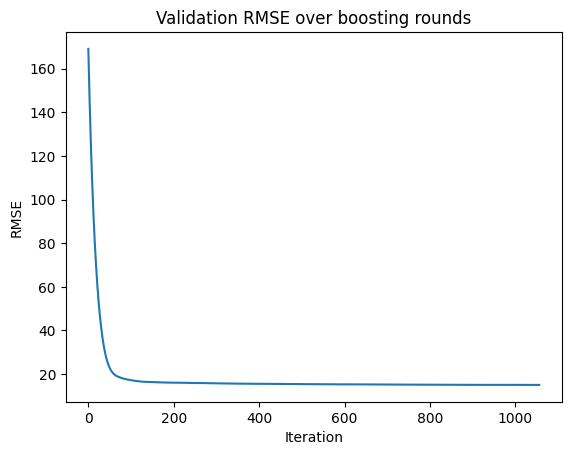

In [28]:
import matplotlib.pyplot as plt

rmse_vals = results["validation_0"]["rmse"]

plt.plot(rmse_vals)
plt.title("Validation RMSE over boosting rounds")
plt.xlabel("Iteration")
plt.ylabel("RMSE")
plt.show()


In [29]:

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)


MAE: 13.951509905595046
RMSE: 19.635465787671574
R2: 0.9589524705511953


In [30]:
results = X_test.copy().reset_index(drop=True)
results["actual_backlog"] = pd.Series(y_test).reset_index(drop=True)
results["predicted_backlog"] = pd.Series(y_pred).reset_index(drop=True)

# Optional: backlog can't be negative
results["predicted_backlog"] = results["predicted_backlog"].clip(lower=0)

In [31]:
results.head(20)

,region,product,orders_created,orders_dispatched,backlog_qty,available_funds,daily_target,depot_status,plant_status,truck_availability_index,...,dispatch_lag_1,dispatch_lag_7,backlog_roll_mean_7,dispatch_roll_mean_7,backlog_cover_days,dispatch_rate,backlog_change,order_gap,actual_backlog,predicted_backlog
0,Lagos,AGO,7,5,445,481494,7,Low Stock,Running,0.99,...,6.0,0.0,436.428571,4.000000,55.625000,0.011211,10.0,2,477.0,448.155975
1,North,PMS,6,7,194,363308,6,Available,Running,0.87,...,4.0,4.0,193.000000,5.857143,27.714286,0.035897,-3.0,-1,197.0,200.726593
2,East,DPK,15,7,313,290160,9,Available,Running,0.95,...,4.0,8.0,302.571429,7.857143,31.300000,0.022293,13.0,8,314.0,321.410370
3,Lagos,DPK,9,5,381,48447,18,Available,Running,0.76,...,11.0,7.0,387.000000,7.857143,20.052632,0.013089,-13.0,4,375.0,387.505737
4,Lagos,PMS,7,9,543,435128,19,Low Stock,Shutdown,0.56,...,6.0,7.0,524.142857,4.000000,27.150000,0.016544,11.0,-2,557.0,542.500122
5,North,DPK,14,8,190,158466,13,Available,Running,0.76,...,10.0,3.0,185.714286,6.000000,13.571429,0.041885,6.0,6,195.0,196.654282
6,East,DPK,8,6,346,259463,9,Available,Shutdown,0.50,...,5.0,5.0,334.142857,6.428571,34.600000,0.017291,15.0,2,364.0,353.231293
7,East,AGO,13,15,264,424473,12,Available,Maintenance,0.37,...,0.0,6.0,260.714286,5.000000,20.307692,0.056604,6.0,-2,285.0,271.874268
8,Lagos,AGO,8,2,328,348355,17,Available,Running,0.97,...,3.0,5.0,316.857143,6.285714,18.222222,0.006079,10.0,6,326.0,335.102234
9,West,DPK,1,8,276,410486,15,Available,Running,0.79,...,2.0,7.0,272.857143,4.714286,17.250000,0.028881,-1.0,-7,306.0,285.104095


In [41]:
#Adding date and customer code to results

results["date"] = df.loc[test_mask, "date"].reset_index(drop=True)
results["customer_code"] = df.loc[test_mask, "customer_code"].reset_index(drop=True)
front_cols = ["date", "customer_code"]
other_cols = [c for c in results.columns if c not in front_cols]

results = results[front_cols + other_cols]



In [42]:
results.head(20)

,date,customer_code,region,product,orders_created,orders_dispatched,backlog_qty,available_funds,daily_target,depot_status,...,dispatch_lag_1,dispatch_lag_7,backlog_roll_mean_7,dispatch_roll_mean_7,backlog_cover_days,dispatch_rate,backlog_change,order_gap,actual_backlog,predicted_backlog
0,2024-07-04,CUST_0535,Lagos,AGO,7,5,445,481494,7,Low Stock,...,6.0,0.0,436.428571,4.000000,55.625000,0.011211,10.0,2,477.0,448.155975
1,2024-07-04,CUST_0534,North,PMS,6,7,194,363308,6,Available,...,4.0,4.0,193.000000,5.857143,27.714286,0.035897,-3.0,-1,197.0,200.726593
2,2024-07-04,CUST_0533,East,DPK,15,7,313,290160,9,Available,...,4.0,8.0,302.571429,7.857143,31.300000,0.022293,13.0,8,314.0,321.410370
3,2024-07-04,CUST_0528,Lagos,DPK,9,5,381,48447,18,Available,...,11.0,7.0,387.000000,7.857143,20.052632,0.013089,-13.0,4,375.0,387.505737
4,2024-07-04,CUST_0531,Lagos,PMS,7,9,543,435128,19,Low Stock,...,6.0,7.0,524.142857,4.000000,27.150000,0.016544,11.0,-2,557.0,542.500122
5,2024-07-04,CUST_0530,North,DPK,14,8,190,158466,13,Available,...,10.0,3.0,185.714286,6.000000,13.571429,0.041885,6.0,6,195.0,196.654282
6,2024-07-04,CUST_0529,East,DPK,8,6,346,259463,9,Available,...,5.0,5.0,334.142857,6.428571,34.600000,0.017291,15.0,2,364.0,353.231293
7,2024-07-04,CUST_0547,East,AGO,13,15,264,424473,12,Available,...,0.0,6.0,260.714286,5.000000,20.307692,0.056604,6.0,-2,285.0,271.874268
8,2024-07-04,CUST_0532,Lagos,AGO,8,2,328,348355,17,Available,...,3.0,5.0,316.857143,6.285714,18.222222,0.006079,10.0,6,326.0,335.102234
9,2024-07-04,CUST_0536,West,DPK,1,8,276,410486,15,Available,...,2.0,7.0,272.857143,4.714286,17.250000,0.028881,-1.0,-7,306.0,285.104095


In [43]:
test_df = df.loc[test_mask].copy()

print("Test rows:", len(test_df))
print("Unique customers:", test_df["customer_code"].nunique())
print("Unique regions:", test_df["region"].nunique())
print("Unique products:", test_df["product"].nunique())


Test rows: 41600
Unique customers: 800
Unique regions: 4
Unique products: 3


In [45]:
##Saving model and pipeline

joblib.dump(pipeline, "backlog_pipeline.pkl")


['backlog_pipeline.pkl']

In [46]:
##loading model to try out predictions with it

pipe = joblib.load("backlog_pipeline.pkl")


In [47]:
##Predict

pred = pipe.predict(X_test)

results = X_test.copy().reset_index(drop=True)
results["predicted_backlog"] = pd.Series(pred).reset_index(drop=True).clip(lower=0)


In [48]:
##Adding critical levels

results["backlog_cover_days"] = results["predicted_backlog"] / (results["daily_target"] + 1)

results["risk_level"] = "LOW"
results.loc[results["backlog_cover_days"] <= 7, "risk_level"] = "MEDIUM"
results.loc[results["backlog_cover_days"] <= 3, "risk_level"] = "HIGH"
results.loc[results["backlog_cover_days"] <= 1, "risk_level"] = "CRITICAL"


In [49]:
##Checks

print(results["risk_level"].value_counts())
print(results[["predicted_backlog","daily_target","backlog_cover_days","risk_level"]].head(20))


risk_level
LOW    41600
Name: count, dtype: int64
    predicted_backlog  daily_target  backlog_cover_days risk_level
0          448.155975             7           56.019497        LOW
1          200.726593             6           28.675228        LOW
2          321.410370             9           32.141037        LOW
3          387.505737            18           20.395039        LOW
4          542.500122            19           27.125006        LOW
5          196.654282            13           14.046734        LOW
6          353.231293             9           35.323129        LOW
7          271.874268            12           20.913405        LOW
8          335.102234            17           18.616791        LOW
9          285.104095            15           17.819006        LOW
10         477.175964            14           31.811731        LOW
11         555.388123            18           29.230954        LOW
12         514.225342             8           57.136149        LOW
13         6